# Decision Tree vs. k-Nearest Neighbors

## Two Non-Parametric Classifiers, Two Different Boundaries

Both models make *no distributional assumptions* about the data — they don't assume Gaussian features or linear boundaries. But they carve up the feature space in completely different ways:

| | Decision Tree | k-Nearest Neighbors |
|---|---|---|
| **Boundary shape** | Axis-aligned rectangles (split on one feature at a time) | Voronoi regions — arbitrary shape determined by local density |
| **Training** | Greedy recursive splitting (fast, stores compact rules) | Store the entire training set (trivial, but expensive later) |
| **Prediction** | O(depth) — follow one path down the tree | O(n·d) — compute distance to all n training points |
| **Interpretability** | High — rules can be printed and read | None — every prediction is an anonymous vote |
| **Complexity control** | `max_depth`, `min_samples_leaf` | k — larger k = smoother boundary |

Your job: run both on the same dataset, tune their complexity parameters, and compare where they succeed and fail.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

plt.rc('figure', figsize=(10, 4))
sns.set_style('darkgrid')

## The Dataset: Wine Recognition

178 Italian wines from three cultivars, described by 13 chemical measurements (alcohol, malic acid, ash, alcalinity, magnesium, phenols, flavanoids, nonflavanoid phenols, proanthocyanins, colour intensity, hue, OD280, proline).

**Target**: cultivar 0, 1, or 2 (three classes).

The classes are reasonably separable but overlap in some projections — enough to make boundary shape matter.

In [2]:
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='cultivar')

print(f'{len(X)} samples, {X.shape[1]} features, {y.nunique()} classes')
print(f'Class counts:\n{y.value_counts().sort_index()}')
X.describe().round(2)

178 samples, 13 features, 3 classes
Class counts:
cultivar
0    59
1    71
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


## Train / Test Split

We standardize for k-NN — it computes Euclidean distances, so unscaled features with large magnitude would dominate. Decision trees are scale-invariant (they only compare relative order), but we apply the same scaling to both for a fair comparison.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {len(X_train)} samples  |  Test: {len(X_test)} samples')

Train: 133 samples  |  Test: 45 samples


---
## Model 1 — Decision Tree

We'll first fit an unconstrained tree (which will almost certainly overfit), then a depth-limited version, and finally sweep over depths to find a good value.

In [4]:
# Full tree (no depth limit)
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train_s, y_train)

dt_full_train_acc = accuracy_score(y_train, dt_full.predict(X_train_s))
dt_full_test_acc  = accuracy_score(y_test,  dt_full.predict(X_test_s))

print(f'Full tree — depth: {dt_full.get_depth()},  leaves: {dt_full.get_n_leaves()}')
print(f'Train accuracy: {dt_full_train_acc:.4f}')
print(f'Test  accuracy: {dt_full_test_acc:.4f}')
print()

Full tree — depth: 4,  leaves: 8
Train accuracy: 1.0000
Test  accuracy: 0.9556

A perfect training accuracy with a large gap to test accuracy is the hallmark of overfitting.


Best depth by 5-fold CV: 3


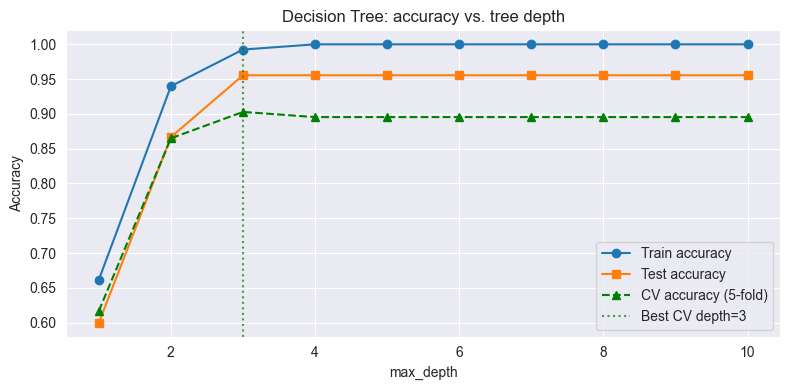

In [5]:
# Sweep max_depth from 1 to 10
depths = range(1, 11)
dt_train_scores, dt_test_scores, dt_cv_scores = [], [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_s, y_train)
    dt_train_scores.append(accuracy_score(y_train, dt.predict(X_train_s)))
    dt_test_scores.append(accuracy_score(y_test,  dt.predict(X_test_s)))
    cv = cross_val_score(dt, X_train_s, y_train, cv=5, scoring='accuracy')
    dt_cv_scores.append(cv.mean())

best_depth = depths[np.argmax(dt_cv_scores)]
print(f'Best depth by 5-fold CV: {best_depth}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths, dt_train_scores, 'o-', label='Train accuracy')
ax.plot(depths, dt_test_scores,  's-', label='Test accuracy')
ax.plot(depths, dt_cv_scores,    '^--', color='green', label='CV accuracy (5-fold)')
ax.axvline(best_depth, color='green', linestyle=':', alpha=0.7, label=f'Best CV depth={best_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree: accuracy vs. tree depth')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Fit the best tree and print it
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_train_s, y_train)

dt_pred = dt_best.predict(X_test_s)
print(f'Decision Tree (depth={best_depth}) test accuracy: {accuracy_score(y_test, dt_pred):.4f}')
print()
print(classification_report(y_test, dt_pred, target_names=data.target_names))

Decision Tree (depth=3) test accuracy: 0.9556

              precision    recall  f1-score   support

     class_0       1.00      0.93      0.97        15
     class_1       0.90      1.00      0.95        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45



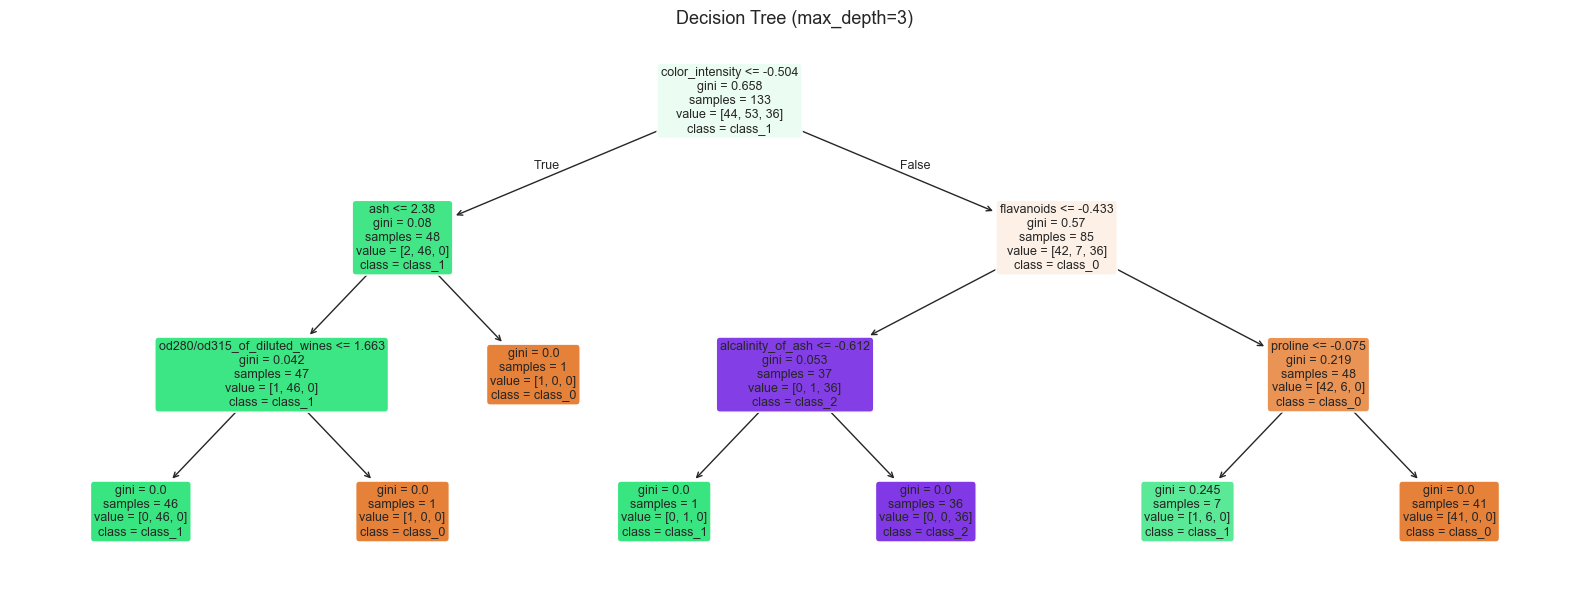

In [7]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(dt_best, feature_names=data.feature_names,
          class_names=data.target_names, filled=True,
          rounded=True, ax=ax, fontsize=9)
ax.set_title(f'Decision Tree (max_depth={best_depth})', fontsize=13)
plt.tight_layout()
plt.show()

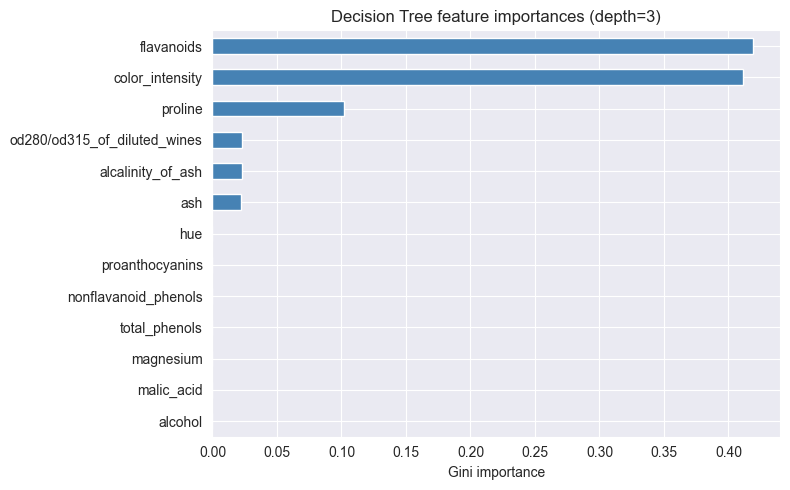

In [8]:
# Feature importances
importances = pd.Series(dt_best.feature_importances_, index=data.feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Gini importance')
ax.set_title(f'Decision Tree feature importances (depth={best_depth})')
plt.tight_layout()
plt.show()

---
## Model 2 — k-Nearest Neighbors

k-NN has no explicit training phase. At prediction time it finds the k closest training points and uses majority vote. The only choice is k — which controls the smoothness of the boundary.

Best k by 5-fold CV: 11


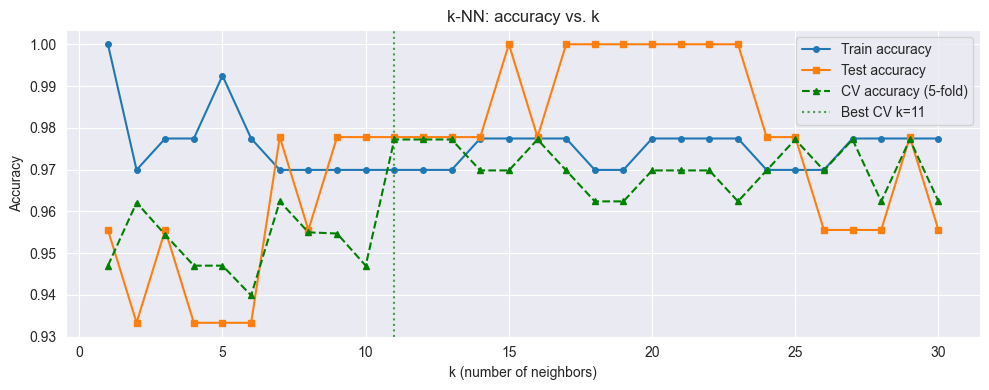

In [9]:
# Sweep k from 1 to 30
ks = range(1, 31)
knn_train_scores, knn_test_scores, knn_cv_scores = [], [], []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    knn_train_scores.append(accuracy_score(y_train, knn.predict(X_train_s)))
    knn_test_scores.append(accuracy_score(y_test,  knn.predict(X_test_s)))
    cv = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='accuracy')
    knn_cv_scores.append(cv.mean())

best_k = list(ks)[np.argmax(knn_cv_scores)]
print(f'Best k by 5-fold CV: {best_k}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(ks), knn_train_scores, 'o-', label='Train accuracy', markersize=4)
ax.plot(list(ks), knn_test_scores,  's-', label='Test accuracy', markersize=4)
ax.plot(list(ks), knn_cv_scores,    '^--', color='green', label='CV accuracy (5-fold)', markersize=4)
ax.axvline(best_k, color='green', linestyle=':', alpha=0.7, label=f'Best CV k={best_k}')
ax.set_xlabel('k (number of neighbors)')
ax.set_ylabel('Accuracy')
ax.set_title('k-NN: accuracy vs. k')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_s, y_train)

knn_pred = knn_best.predict(X_test_s)
print(f'k-NN (k={best_k}) test accuracy: {accuracy_score(y_test, knn_pred):.4f}')
print()
print(classification_report(y_test, knn_pred, target_names=data.target_names))

k-NN (k=11) test accuracy: 0.9778

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      0.94      0.97        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



---
## Head-to-Head: Decision Boundaries

13 dimensions are hard to visualize. We'll use PCA to project the data to 2D and plot decision boundaries in that reduced space.

Note: the boundaries shown are for models trained on the 2D PCA projection, not on the full 13-feature dataset. They won't match the accuracy numbers above exactly — but they give intuition for *how* each model partitions space.

Variance explained by 2 PCs: 55.0%


/var/folders/r7/7_r15vgx6n38wlfw3g8xz8t00000gn/T/ipykernel_60072/3149161345.py:41: UserWarning: Glyph 9711 (\N{LARGE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/chelseatroy/.pyenv/versions/3.10.8/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9711 (\N{LARGE CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


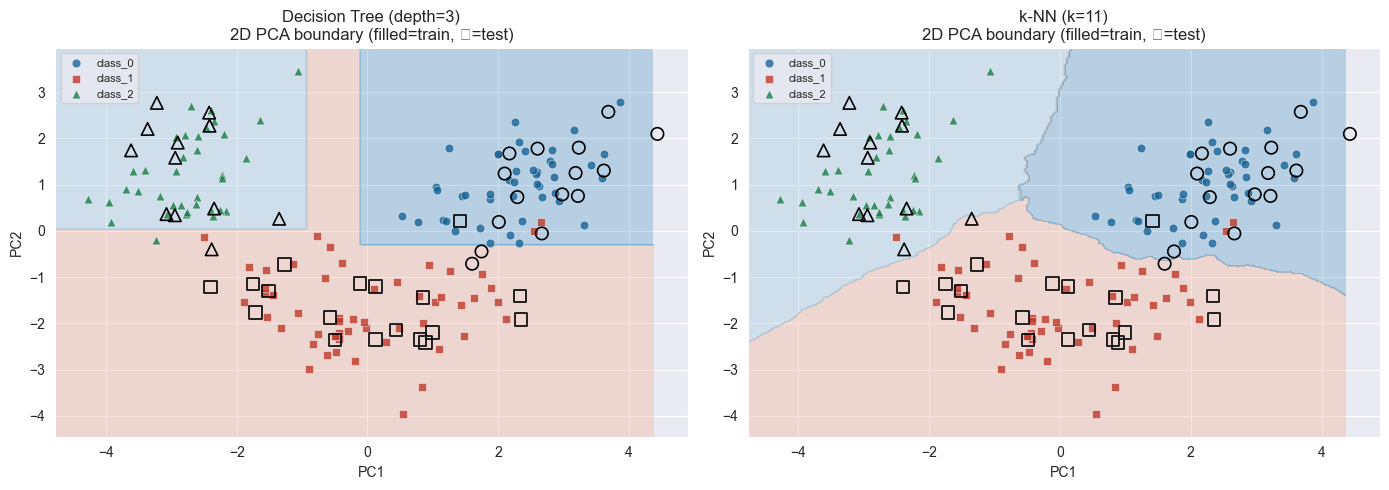

In [11]:
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_s)
X_test_2d  = pca.transform(X_test_s)
print(f'Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}')

# Fit both models on the 2D projection
dt_2d  = DecisionTreeClassifier(max_depth=best_depth, random_state=42).fit(X_train_2d, y_train)
knn_2d = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_2d, y_train)

# Build a mesh grid
x_min, x_max = X_train_2d[:,0].min()-0.5, X_train_2d[:,0].max()+0.5
y_min, y_max = X_train_2d[:,1].min()-0.5, X_train_2d[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

colors = ['#4393c3', '#f4a582', '#92c5de']
cmap   = plt.cm.colors.ListedColormap(colors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, title in zip(axes,
                              [dt_2d, knn_2d],
                              [f'Decision Tree (depth={best_depth})', f'k-NN (k={best_k})']):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    for cls, marker, color in zip([0,1,2], ['o','s','^'], ['#1a6496','#c0392b','#1a7a4a']):
        mask = y_train.values == cls
        ax.scatter(X_train_2d[mask,0], X_train_2d[mask,1],
                   marker=marker, color=color, s=40, alpha=0.8,
                   edgecolors='white', linewidths=0.4, label=data.target_names[cls])
    # Test points with black border
    for cls, marker in zip([0,1,2], ['o','s','^']):
        mask = y_test.values == cls
        ax.scatter(X_test_2d[mask,0], X_test_2d[mask,1],
                   marker=marker, s=80, alpha=1.0,
                   edgecolors='black', linewidths=1.2, facecolors='none')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'{title}\n2D PCA boundary (filled=train, ◯=test)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
# Summary
pd.DataFrame({
    'Model': [f'Decision Tree (depth={best_depth})', f'k-NN (k={best_k})'],
    'Test Accuracy': [accuracy_score(y_test, dt_pred), accuracy_score(y_test, knn_pred)],
    'Prediction time scales with': ['O(depth)', 'O(n × d)'],
    'Human-readable?': ['Yes — print the tree', 'No']
}).set_index('Model')

,Test Accuracy,Prediction time scales with,Human-readable?
Model,,,
Decision Tree (depth=3),0.955556,O(depth),Yes — print the tree
k-NN (k=11),0.977778,O(n × d),No


---
## Discussion Questions

1. **Overfitting profiles**: Look at the depth/k sweep plots. For the decision tree, at what depth does train accuracy reach 1.0 while test accuracy starts to drop? For k-NN, what happens to train accuracy as k decreases toward 1 — and why is k=1 train accuracy always exactly 1.0?

2. **The boundary plots**: What shapes does the decision tree boundary create? What shapes does k-NN create? Can you point to a region where one model's boundary looks more sensible than the other's?

3. **Feature importances**: The decision tree tells you which features it used and how much it relied on each. k-NN uses all features equally (via Euclidean distance). How might you give k-NN access to feature importance information?

4. **Class 1 performance**: Check the per-class precision and recall in both classification reports. Is one class consistently harder for both models? Why might that be? (Hint: look at the class counts.)

5. **PCA boundary vs. full model**: The boundary visualizations use only 2 PCA dimensions, but the actual models used 13 features. The accuracy numbers for the 2D models will be lower. How much does reducing to 2D cost in accuracy, and what does that tell you about the dataset's intrinsic dimensionality?

6. **When would you choose each?** List one scenario where you'd strongly prefer the decision tree, and one where you'd strongly prefer k-NN. Justify both.